In [ ]:
1. Klasifikasi Flynn

    Operasi arr + arr pada NumPy array: SIMD (Single Instruction, Multiple Data)

        Alasan: NumPy memanfaatkan instruksi vektor pada CPU (seperti AVX/SSE). Satu instruksi penjumlahan dieksekusi secara sejajar terhadap banyak elemen data (vektor/array) dalam satu waktu.

    Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris: SISD (Single Instruction, Single Data)

        Alasan: Program berjalan secara serial pada satu core CPU, mengeksekusi satu aliran instruksi secara berurutan untuk memproses satu data (baris) pada satu waktu.

    Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen: MIMD (Multiple Instruction, Multiple Data)

        Alasan: Setiap node pada cluster merupakan komputer independen yang mengeksekusi instruksi/kode programnya sendiri terhadap himpunan data wilayahnya masing-masing secara bersamaan.

   Input Size (N)  perf_counter (s)  timeit (s)
0            6000          0.008715    0.008971
1           12000          0.015685    0.012685
2           24000          0.031547    0.030635
3           48000          0.081344    0.083836


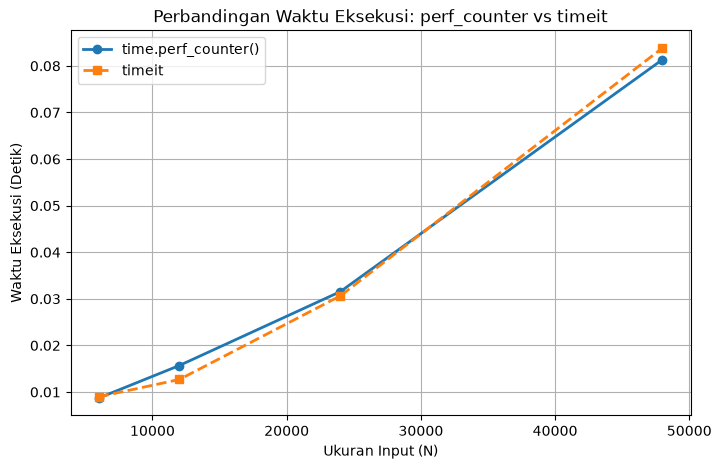

In [12]:
#2.
import time
import timeit
import matplotlib.pyplot as plt
import pandas as pd


def hitung_prima(n):
  count = 0
  for i in range(2, n):
    is_prime = True
    for j in range(2, int(i**0.5) + 1):
      if i % j == 0:
        is_prime = False
        break
    if is_prime:
      count += 1
  return count


input_sizes = [6000, 12000, 24000, 48000]
waktu_perf = []
waktu_timeit = []

for n in input_sizes:
  start = time.perf_counter()
  hitung_prima(n)
  end = time.perf_counter()
  waktu_perf.append(end - start)

  t = timeit.timeit(lambda: hitung_prima(n), number=1)
  waktu_timeit.append(t)

df = pd.DataFrame({
    "Input Size (N)": input_sizes,
    "perf_counter (s)": waktu_perf,
    "timeit (s)": waktu_timeit,
})
print(df)

plt.figure(figsize=(8, 5))
plt.plot(
    input_sizes,
    waktu_perf,
    marker="o",
    label="time.perf_counter()",
    linewidth=2,
)
plt.plot(
    input_sizes,
    waktu_timeit,
    marker="s",
    linestyle="--",
    label="timeit",
    linewidth=2,
)
plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (Detik)")
plt.title("Perbandingan Waktu Eksekusi: perf_counter vs timeit")
plt.legend()
plt.grid(True)
plt.show()

N	Speedup
---------------
2	1.74
4	2.76
8	3.90
16	4.92
32	5.66
64	6.12


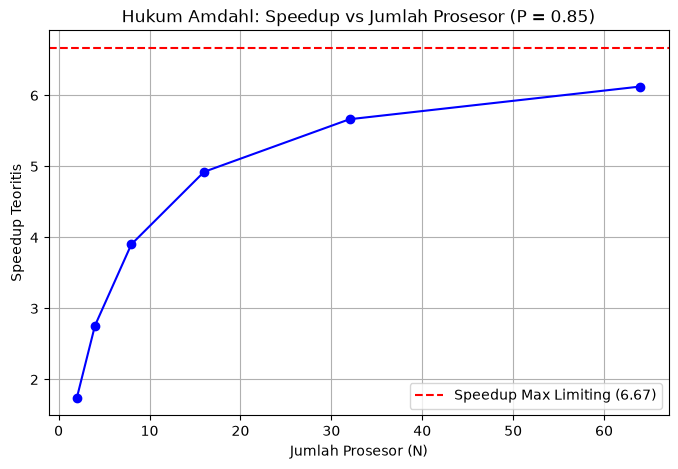

In [13]:
#3.
import matplotlib.pyplot as plt
import numpy as np


def amdahl_speedup(P, N):
  return 1 / ((1 - P) + (P / N))


P = 0.85
N_values = [2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, n) for n in N_values]

print("N\tSpeedup")
print("-" * 15)
for n, s in zip(N_values, speedups):
  print(f"{n}\t{s:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker="o", color="b", linestyle="-")
plt.title("Hukum Amdahl: Speedup vs Jumlah Prosesor (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup Teoritis")
plt.grid(True)
plt.axhline(
    y=1 / (1 - P),
    color="r",
    linestyle="--",
    label=f"Speedup Max Limiting ({1/(1-P):.2f})",
)
plt.legend()
plt.show()

In [ ]:
4. Refleksi Singkat

Hukum Amdahl lebih relevan digunakan ketika ukuran masalah atau beban kerja tetap, tetapi jumlah prosesor ditambah untuk mempercepat penyelesaian tugas. Hukum ini membantu memperkirakan batas maksimum peningkatan kinerja akibat adanya bagian program yang tidak dapat diparalelkan. Contoh kasus nyata adalah menjalankan aplikasi pengolahan gambar dengan ukuran gambar yang tetap pada komputer dengan jumlah core CPU yang berbeda. Meskipun jumlah core ditambah, bagian program yang bersifat serial tetap membatasi speedup.
Sebaliknya, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Hukum ini menunjukkan bahwa sistem paralel dapat menyelesaikan masalah yang lebih besar dalam waktu yang relatif sama. Contoh nyata adalah simulasi cuaca menggunakan superkomputer. Dengan menambah jumlah prosesor, peneliti dapat meningkatkan resolusi simulasi, memperluas wilayah yang dianalisis, atau memperpanjang periode prediksi tanpa harus meningkatkan waktu eksekusi secara signifikan.